In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [7]:
s = [1.1, 1., 1.]

d = np.array([10., 10., 10.])
tol = 1.e-6
for itr in range(50):
    aa, bb, cc = d[0]+s[0], d[1]+s[1], d[2]+s[2]
    C = aa*bb*cc - 1
    partial_C = np.array([bb*cc, aa*cc, aa*bb])
    
    d_tmp = (partial_C.dot(d)-C)/np.linalg.norm(partial_C)**2 * partial_C
    d_error = np.linalg.norm(d-d_tmp)
    d = d_tmp
    if d_error < tol:
        break
print(f's: {s}')
print(f'd: {d}')
print(f'sigma *: {[aa, bb, cc]}')
print(f'constraint: {aa*bb*cc-1}')
print(f'distance: {np.linalg.norm(d)}')
print(f'volume change: {np.abs(np.prod(s)-1)}')

s: [1.1, 1.0, 1.0]
d: [-0.03003904 -0.03324588 -0.03324588]
sigma *: [1.0699608105953937, 0.966754193181366, 0.966754193181366]
constraint: -1.7148726882965093e-11
distance: 0.055793550173777746
volume change: 0.10000000000000009


斜率: 0.5742554165682292


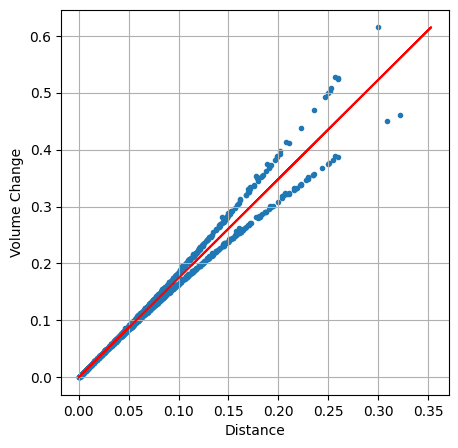

In [79]:
# 三维情况
distance_list = []
volume_change_list = []
for i in range(1000):
    s = np.random.normal(loc=1., scale=0.1, size=3)

    d = np.array([10., 10., 10.])
    tol = 1.e-6
    for itr in range(50):
        aa, bb, cc = d[0]+s[0], d[1]+s[1], d[2]+s[2]
        C = aa*bb*cc - 1
        partial_C = np.array([bb*cc, aa*cc, aa*bb])
        
        d_tmp = (partial_C.dot(d)-C)/np.linalg.norm(partial_C)**2 * partial_C
        d_error = np.linalg.norm(d-d_tmp)
        d = d_tmp
        if d_error < tol:
            break
    distance_list.append(np.linalg.norm(d))
    volume_change_list.append(np.abs(np.prod(s)-1))

A = np.array(volume_change_list)[:, np.newaxis]
slope, _, _, _ = np.linalg.lstsq(A, np.array(distance_list), rcond=None)
print(f'斜率: {slope[0]}')    

# 使用拟合的斜率和截距计算拟合的y值
distance_fit = slope * np.array(volume_change_list)
    
fig, axs = plt.subplots(1, 1, figsize=(5, 5), dpi=100)
axs.scatter(distance_list, volume_change_list, marker='.')
axs.plot(distance_fit, volume_change_list, color='red')
axs.set_xlabel('Distance')
axs.set_ylabel('Volume Change')
# axs.set_aspect('equal', adjustable='box')
axs.grid(True)

plt.show()

斜率: 0.7077195302695631


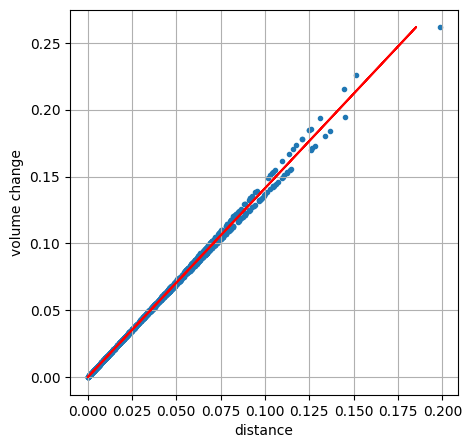

In [77]:
# 二维情况
distance_list = []
volume_change_list = []
for i in range(1000):
    s = np.random.normal(loc=1., scale=0.05, size=2)

    d = np.array([10., 10.])
    tol = 1.e-6
    for itr in range(50):
        aa, bb = d[0]+s[0], d[1]+s[1]
        C = aa*bb - 1
        partial_C = np.array([bb, aa])
        
        d_tmp = (partial_C.dot(d)-C)/np.linalg.norm(partial_C)**2 * partial_C
        d_error = np.linalg.norm(d-d_tmp)
        d = d_tmp
        if d_error < tol:
            break
    distance_list.append(np.linalg.norm(d))
    volume_change_list.append(np.abs(np.prod(s)-1))
    
A = np.array(volume_change_list)[:, np.newaxis]
slope, _, _, _ = np.linalg.lstsq(A, np.array(distance_list), rcond=None)
# print(f'斜率: {slope}. 截距: {intercept}')
print(f"斜率: {slope[0]}")

# 使用拟合的斜率和截距计算拟合的y值
distance_fit = slope * np.array(volume_change_list)
    
fig, axs = plt.subplots(1, 1, figsize=(5, 5), dpi=100)
axs.scatter(distance_list, volume_change_list, marker='.')
axs.plot(distance_fit, volume_change_list, color='red')
axs.set_xlabel('distance')
axs.set_ylabel('volume change')
# axs.set_aspect('equal', adjustable='box')
axs.grid(True)

plt.show()